# Trend Detector: Forecasting Topic Popularity Growth

This project predicts **future popularity growth** of topics using historical
graph/network features (PageRank, centrality, degree, etc.).  
We model **growth** instead of raw PageRank because:

- Raw PageRank rewards topics that are *already* popular.
- Growth captures **momentum**, which signals “trending.”

We also compare every model to a **naive baseline** that predicts **zero growth**.
This ensures the model is adding real predictive value beyond autocorrelation.

The notebook includes:
- Time‑series cross‑validation (no leakage)
- XGBoost regression + classification
- Multi‑year recursive forecasting (2027–2031)
- Uncertainty that grows with forecast horizon
- Final ranked list of “topics likely to gain traction next year”


In [21]:
# %%
import pandas as pd
import numpy as np

from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [22]:
# %%
ALL_YEARS_URL = "https://raw.githubusercontent.com/Damone-Washington19/Winmaxxers/main/data-prep/Features/all_years_features.csv"

df = pd.read_csv(ALL_YEARS_URL)

print("Head:")
display(df.head())

print("\nRow counts per year:")
print(df["year"].value_counts().sort_index())

print("\nMissing values:")
print(df.isna().sum())

print("\nUnique topics:")
print("page_id:", df["page_id"].nunique())
print("title:", df["title"].nunique())


Head:


,page_id,title,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,closeness_centrality,eigenvector_centrality,katz_centrality,hub_score,authority_score,clustering_coefficient,core_number,avg_neighbor_degree,avg_neighbor_pagerank,community_size,bridging_score,year
0,21488,Nanotechnology,146,41,187,0.029995,0.118767,0.180140,0,0.049822,0.012427,8.087311e-02,0.013739,7,6.390244,0.001004,135,0.000632,2020
1,60786392,Nanotechnology in warfare,1,3,4,0.000243,0.000029,0.081009,0,0.026571,0.005013,3.108192e-04,0.333333,4,19.333333,0.010122,135,0.000006,2020
2,14431229,Outline of nanotechnology,1,89,90,0.000218,0.000105,0.000698,0,0.038566,0.031149,7.927841e-04,0.052684,7,6.325843,0.002104,77,0.000001,2020
3,7064233,History of nanotechnology,3,17,20,0.000883,0.002138,0.136466,0,0.028838,0.005339,5.749435e-03,0.215789,7,4.823529,0.004220,123,0.000102,2020
4,49615253,5D optical data storage,1,0,1,0.000524,0.000000,0.001257,0,0.026011,-0.000000,-1.099391e-19,0.000000,1,0.000000,0.001101,4,0.000000,2020



Row counts per year:
year
2020    1433
2021    1474
2022    1509
2023    1532
2024    1570
2025    1605
2026    1621
Name: count, dtype: int64

Missing values:
page_id                   0
title                     0
in_degree                 0
out_degree                0
total_degree              0
pagerank                  0
betweenness_centrality    0
closeness_centrality      0
eigenvector_centrality    0
katz_centrality           0
hub_score                 0
authority_score           0
clustering_coefficient    0
core_number               0
avg_neighbor_degree       0
avg_neighbor_pagerank     0
community_size            0
bridging_score            0
year                      0
dtype: int64

Unique topics:
page_id: 1622
title: 1622


In [23]:
# %%
df = df.sort_values(["page_id", "year"]).reset_index(drop=True)

# Rank percentile
df["pagerank_rank"] = df.groupby("year")["pagerank"].rank(ascending=False)
df["pagerank_rank_percentile"] = df.groupby("year")["pagerank_rank"].transform(
    lambda r: 1 - (r - 1) / (r.max() - 1 if r.max() > 1 else 1)
)

# Next-year pagerank
df["pagerank_next_year"] = df.groupby("page_id")["pagerank"].shift(-1)
df["year_next"] = df.groupby("page_id")["year"].shift(-1)

mask = (df["pagerank_next_year"].notna()) & (df["year_next"] == df["year"] + 1)
df_target = df.loc[mask].copy()

# Growth target
df_target["pagerank_growth"] = (
    df_target["pagerank_next_year"] - df_target["pagerank"]
) / df_target["pagerank"]

# Lagged features
df_target["pagerank_lag_1"] = df_target.groupby("page_id")["pagerank"].shift(1)
df_target["pagerank_lag_2"] = df_target.groupby("page_id")["pagerank"].shift(2)

df_target = df_target.dropna(subset=["pagerank_lag_1", "pagerank_lag_2"])

print("Final training rows:", df_target.shape)


Final training rows: (5938, 26)


In [24]:
# %%
def evaluate_baseline(y_true):
    y_pred = np.zeros_like(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


In [25]:
# %%
df_target["pagerank_growth_clipped"] = df_target.groupby("year")["pagerank_growth"]\
    .transform(lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99)))

target_col = "pagerank_growth_clipped"


In [26]:
# %%
exclude = [
    "pagerank_growth", "pagerank_growth_clipped",
    "pagerank_next_year", "year_next",
    "page_id", "title", "year",
    "pagerank_rank", "pagerank_rank_percentile"
]

feature_cols = [
    c for c in df_target.columns
    if c not in exclude and df_target[c].dtype != "object"
]

param_grid = {
    "n_estimators": [200],
    "max_depth": [4],
    "learning_rate": [0.1]
}

years = sorted(df_target["year"].unique())
folds = []
for y in years[:-1]:
    train_mask = df_target["year"] <= y
    test_mask = df_target["year"] == (y + 1)
    if df_target[test_mask].empty:
        continue
    folds.append((y, train_mask, test_mask))

results_regression = []

for params in ParameterGrid(param_grid):
    fold_metrics = []
    print(f"\n=== Evaluating params: {params} ===")

    for y, train_mask, test_mask in folds:
        train = df_target.loc[train_mask]
        test = df_target.loc[test_mask]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_test = test[feature_cols].values
        y_test = test[target_col].values

        b_mae, b_rmse, b_r2 = evaluate_baseline(y_test)

        model = XGBRegressor(
            random_state=RANDOM_STATE,
            objective="reg:squarederror",
            **params
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        fold_metrics.append({
            "train_year": y,
            "test_year": y+1,
            "baseline_mae": b_mae,
            "model_mae": mae,
            "baseline_r2": b_r2,
            "model_r2": r2
        })

        print(f"Fold train<= {y}, test={y+1}")
        print(f"  Baseline MAE={b_mae:.4f}, R2={b_r2:.4f}")
        print(f"  Model    MAE={mae:.4f}, R2={r2:.4f}")

    avg_mae = np.mean([m["model_mae"] for m in fold_metrics])
    results_regression.append({"params": params, "avg_mae": avg_mae})

best_reg = min(results_regression, key=lambda r: r["avg_mae"])
best_reg



=== Evaluating params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200} ===
Fold train<= 2022, test=2023
  Baseline MAE=0.0843, R2=-0.0011
  Model    MAE=0.1377, R2=-0.6764
Fold train<= 2023, test=2024
  Baseline MAE=0.0987, R2=-0.0184
  Model    MAE=0.1201, R2=-0.4382
Fold train<= 2024, test=2025
  Baseline MAE=0.0342, R2=-0.0000
  Model    MAE=0.0765, R2=-0.8694


{'params': {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200},
 'avg_mae': np.float64(0.11140055187269919)}

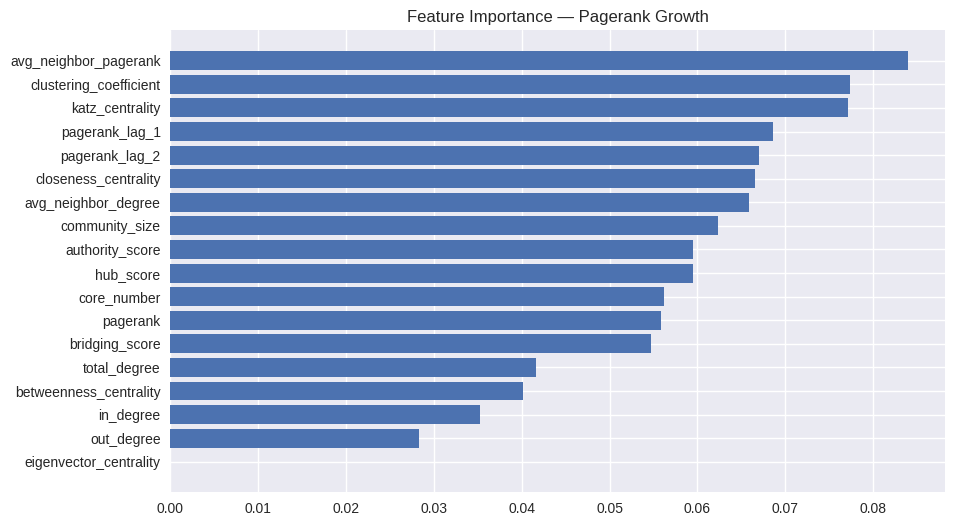

In [27]:
# %%
X_all = df_target[feature_cols].values
y_all = df_target[target_col].values

final_regressor = XGBRegressor(
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    **best_reg["params"]
)
final_regressor.fit(X_all, y_all)

importances = final_regressor.feature_importances_
fi_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.title("Feature Importance — Pagerank Growth")
plt.show()


In [28]:
# %%
latest_year = df_target["year"].max()
df_current = df[df["year"] == latest_year].copy()

df_sorted = df.sort_values(["page_id", "year"]).copy()
df_sorted["pagerank_lag_1"] = df_sorted.groupby("page_id")["pagerank"].shift(1)
df_sorted["pagerank_lag_2"] = df_sorted.groupby("page_id")["pagerank"].shift(2)

df_current = df_current.merge(
    df_sorted[["page_id", "year", "pagerank_lag_1", "pagerank_lag_2"]],
    on=["page_id", "year"],
    how="left"
).dropna(subset=["pagerank_lag_1", "pagerank_lag_2"])

X_curr = df_current[feature_cols].values
df_current["predicted_growth"] = final_regressor.predict(X_curr)
df_current["predicted_pagerank_next"] = df_current["pagerank"] * (1 + df_current["predicted_growth"])

df_current.head()


,page_id,title,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,closeness_centrality,eigenvector_centrality,katz_centrality,...,bridging_score,year,pagerank_rank,pagerank_rank_percentile,pagerank_next_year,year_next,pagerank_lag_1,pagerank_lag_2,predicted_growth,predicted_pagerank_next
0,2080,A Fire Upon the Deep,1,0,1,0.000207,0.000000,0.000831,0,0.024556,...,0.000000,2025,889.5,0.294281,0.000174,2026.0,0.000220,0.000228,-0.036029,0.000199
1,3211,Atom probe,0,1,1,0.000175,0.000000,0.000000,0,0.024553,...,0.000000,2025,1260.0,0.000000,0.000174,2026.0,0.000186,0.000193,-0.012032,0.000173
2,5320,Carbon nanotube,38,17,55,0.007366,0.028956,0.174178,0,0.031386,...,0.000517,2025,4.0,0.997617,0.007108,2026.0,0.005962,0.006110,0.002326,0.007383
3,6111,Chemical vapor deposition,21,9,30,0.003916,0.006051,0.153859,0,0.027557,...,0.000195,2025,29.0,0.977760,0.004354,2026.0,0.004012,0.003532,0.038486,0.004067
4,8484,Deus Ex (video game),4,0,4,0.000605,0.000000,0.124174,0,0.024954,...,0.000000,2025,413.0,0.672756,0.000600,2026.0,0.000500,0.000530,-0.021689,0.000591


In [29]:
# %%
structural_features = [
    c for c in feature_cols
    if "pagerank" not in c and "lag" not in c
]

df_hist = df.sort_values(["page_id", "year"]).copy()
yoY_change = {}

for feat in structural_features:
    df_hist[f"{feat}_pct"] = df_hist.groupby("page_id")[feat].pct_change()
    yoY_change[feat] = df_hist[f"{feat}_pct"].mean()

historical_rmse = best_reg["avg_mae"]

def recursive_forecast(df_start, start_year, end_year):
    forecasts = []
    curr = df_start.copy()

    for step, year in enumerate(range(start_year + 1, end_year + 1), start=1):
        X = curr[feature_cols].values
        curr["predicted_growth"] = final_regressor.predict(X)
        curr["pagerank"] *= (1 + curr["predicted_growth"])
        curr["year"] = year

        for feat in structural_features:
            curr[feat] *= (1 + yoY_change.get(feat, 0))

        uncertainty = historical_rmse * step

        for _, row in curr.iterrows():
            forecasts.append({
                "page_id": row["page_id"],
                "title": row["title"],
                "year": year,
                "predicted_pagerank": row["pagerank"],
                "predicted_growth": row["predicted_growth"],
                "uncertainty": uncertainty
            })

    return pd.DataFrame(forecasts)

forecast_df = recursive_forecast(df_current.copy(), latest_year, 2031)
forecast_df.head()


,page_id,title,year,predicted_pagerank,predicted_growth,uncertainty
0,2080,A Fire Upon the Deep,2026,0.000199,-0.036029,0.111401
1,3211,Atom probe,2026,0.000173,-0.012032,0.111401
2,5320,Carbon nanotube,2026,0.007383,0.002326,0.111401
3,6111,Chemical vapor deposition,2026,0.004067,0.038486,0.111401
4,8484,Deus Ex (video game),2026,0.000591,-0.021689,0.111401


In [30]:
# %%
df_cls = df_target.copy()
df_cls["trending"] = 0

for y in df_cls["year"].unique():
    sub = df_cls[df_cls["year"] == y]
    thresh = np.percentile(sub[target_col], 90)
    df_cls.loc[(df_cls["year"] == y) & (df_cls[target_col] >= thresh), "trending"] = 1


In [31]:
# %%
cls_results = []

for y, train_mask, test_mask in folds:
    train = df_cls.loc[train_mask]
    test = df_cls.loc[test_mask]

    X_train = train[feature_cols].values
    y_train = train["trending"].values
    X_test = test[feature_cols].values
    y_test = test["trending"].values

    clf = XGBClassifier(
        random_state=42,
        max_depth=4,
        n_estimators=200,
        learning_rate=0.1
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )

    cls_results.append({
        "train_year": y,
        "test_year": y+1,
        "precision": p,
        "recall": r,
        "f1": f1
    })

pd.DataFrame(cls_results)


,train_year,test_year,precision,recall,f1
0,2022,2023,0.238095,0.033784,0.059172
1,2023,2024,0.107143,0.019868,0.033520
2,2024,2025,0.200000,0.006536,0.012658


,title,pagerank,predicted_growth,predicted_pagerank_next
109,Dichroic prism,0.000175,0.335349,0.000233
207,Dichroic filter,0.000175,0.316707,0.000230
1211,Germanium-vacancy center in diamond,0.000175,0.308672,0.000229
110,Optical coating,0.000175,0.282325,0.000224
783,Quantum dot display,0.000604,0.264464,0.000763
439,Charles M. Lieber,0.000539,0.239544,0.000668
152,Nanosys,0.000476,0.170627,0.000557
408,Nanochemistry,0.000468,0.165154,0.000545
460,Transfersome,0.000175,0.155695,0.000202
791,SEEC microscopy,0.002935,0.147803,0.003369


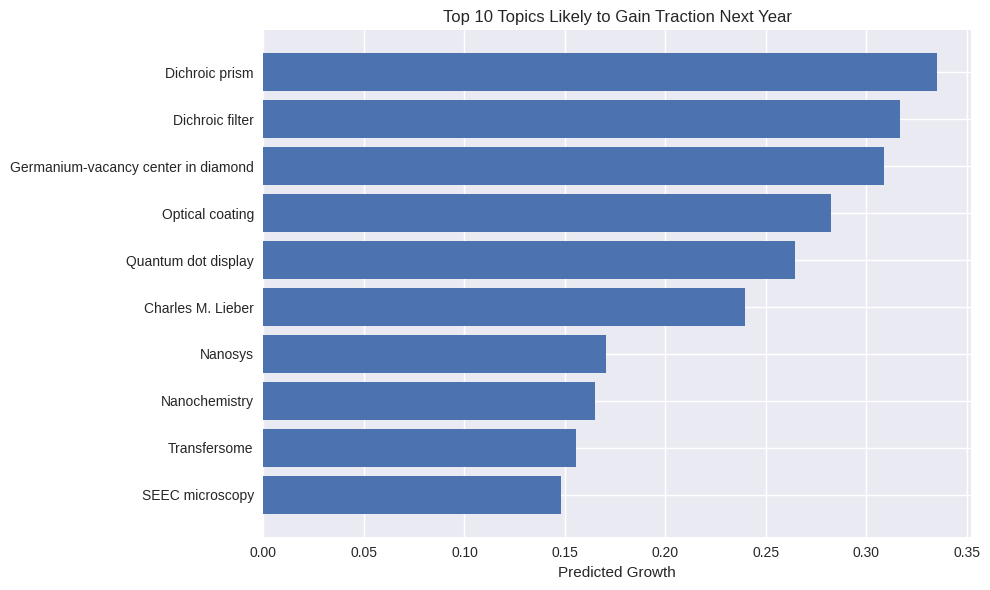

In [32]:
# %%
ranked = df_current.sort_values("predicted_growth", ascending=False)

top10 = ranked.head(10)
display(top10[["title", "pagerank", "predicted_growth", "predicted_pagerank_next"]])

plt.figure(figsize=(10, 6))
plt.barh(top10["title"], top10["predicted_growth"])
plt.gca().invert_yaxis()
plt.xlabel("Predicted Growth")
plt.title("Top 10 Topics Likely to Gain Traction Next Year")
plt.tight_layout()
plt.show()
